# This Notebook was used on Kaggle to use the Neural Networks (`MTCNN`, `Xception`)

In [9]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import cv2
import requests
from PIL import Image
from io import BytesIO
from mtcnn import MTCNN
from tensorflow.keras.applications.xception import Xception, preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array

In [10]:
df = pd.read_csv("/kaggle/input/datasets/chuneeb/deepfake-detection-dataset-2026/FINAL_DATASET.csv")
df.sample(5)

,image_id,image_url,label,label_numeric,category,gender,age_group,source,fake_method,image_quality,resolution,confidence_score,detection_difficulty,dataset_split,date_collected,version,year
5631,5632,https://api.multiavatar.com/face75.jpg,FAKE,0,AI Generated,Unknown,18-25,MultiSource,StyleGAN3,High,1024x1024,0.92,Hard,train,2026-04-26,v2.0,2026
1657,1658,https://images.unsplash.com/photo-158983739603...,REAL,1,Authentic,Unknown,18-25,Unsplash,NaN,High,1080x1080,0.88,Easy,train,2026-02-03,v2.0,2026
1705,1706,https://images.unsplash.com/photo-163354944605...,REAL,1,Authentic,Male,50+,Unsplash,NaN,High,1080x1080,0.85,Easy,train,2026-04-23,v2.0,2026
923,924,https://images.unsplash.com/photo-157059157779...,REAL,1,Authentic,Male,26-35,Unsplash,NaN,Medium,1080x1080,0.87,Easy,train,2026-03-20,v2.0,2026
853,854,https://images.unsplash.com/photo-158540262708...,REAL,1,Authentic,Female,26-35,Unsplash,NaN,High,1080x1080,0.91,Easy,train,2026-03-05,v2.0,2026


In [11]:
train_df = df[df["dataset_split"] == "train"]
test_df = df[df["dataset_split"] == "test"]

<Axes: xlabel='label_numeric', ylabel='count'>

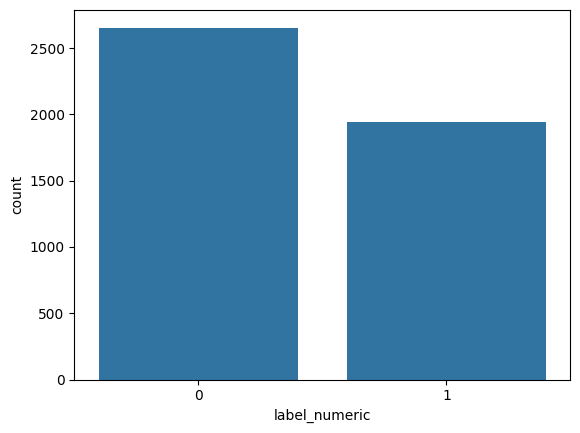

In [12]:
X_train = train_df["image_url"]
y_train = train_df["label_numeric"]
sns.countplot(train_df, x="label_numeric")

In [16]:
def preprocess_image_to_array(url):
    try:
        # Fetch and decode
        resp = requests.get(url, timeout=5)
        img = tf.image.decode_jpeg(resp.content, channels=3)
        img_np = img.numpy()
        
        # Face Detection
        results = detector.detect_faces(img_np)
        if results:
            x, y, w, h = results[0]['box']
            # Apply 20% margin
            mw, mh = int(w * 0.1), int(h * 0.1)
            img_np = img_np[max(0, y-mh):y+h+mh, max(0, x-mw):x+w+mw]
        
        # Resize to Xception size
        img_resized = tf.image.resize(img_np, [299, 299])
        return img_resized.numpy()
    except:
        return np.zeros((299, 299, 3))

In [17]:
all_features = []
for i, url in enumerate(X_train[:3]):
    print(f"Processing image {i}...")
    img_array = preprocess_image_to_array(url) 
    x = np.expand_dims(img_array, axis=0)
    x = preprocess_input(x)
    features = base_model.predict(x, verbose=0)
    all_features.append(features.flatten())

print("Debug successful!")

Processing image 0...


I0000 00:00:1778245185.127285    3640 service.cc:152] XLA service 0x7b79280018e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778245185.127320    3640 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778245185.682150    3640 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778245192.195695    3640 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Processing image 1...
Processing image 2...
Debug successful!


In [18]:
detector = MTCNN()
# pooling='avg' ensures we get the 1D 2048 vector immediately
base_model = Xception(weights='imagenet', include_top=False, pooling='avg')

all_features = []

print("Starting streaming extraction...")

for i, url in enumerate(X_train):
    try:
        # A. Download and detect (CPU)
        img_array = preprocess_image_to_array(url) # Using the function from earlier
        
        # B. Prepare for model
        x = np.expand_dims(img_array, axis=0)
        x = preprocess_input(x)
        
        # C. Extract features (GPU)
        # verbose=0 keeps the console clean
        features = base_model.predict(x, verbose=0)
        
        # D. Store only the small vector (2048 floats ~ 8KB)
        all_features.append(features.flatten())
        
        if i % 100 == 0:
            print(f"Processed {i}/4593...")
            
    except Exception as e:
        # If an image fails, append zeros to keep your X and Y aligned
        all_features.append(np.zeros((2048,)))

# 2. Final conversion to the 2D array for Random Forest
X_features = np.array(all_features)
print(f"Done! Final shape: {X_features.shape}")

Starting streaming extraction...
Processed 0/4593...
Processed 100/4593...
Processed 200/4593...
Processed 300/4593...
Processed 400/4593...
Processed 500/4593...
Processed 600/4593...
Processed 700/4593...
Processed 800/4593...
Processed 900/4593...
Processed 1000/4593...
Processed 1100/4593...
Processed 1200/4593...
Processed 1300/4593...
Processed 1400/4593...
Processed 1500/4593...
Processed 1600/4593...
Processed 1700/4593...
Processed 1800/4593...
Processed 1900/4593...
Processed 2000/4593...
Processed 2100/4593...
Processed 2200/4593...
Processed 2300/4593...
Processed 2400/4593...
Processed 2500/4593...
Processed 2600/4593...
Processed 2700/4593...
Processed 2800/4593...
Processed 2900/4593...
Processed 3000/4593...
Processed 3100/4593...
Processed 3200/4593...
Processed 3300/4593...
Processed 3400/4593...
Processed 3500/4593...
Processed 3600/4593...
Processed 3700/4593...
Processed 3800/4593...
Processed 3900/4593...
Processed 4000/4593...
Processed 4100/4593...
Processed 420

In [19]:
print(f"Number of non-zero rows: {np.count_nonzero(np.any(X_features != 0, axis=1))}")
print(f"Sample of first row: {X_features[0][:10]}")

Number of non-zero rows: 4593
Sample of first row: [0.         0.00320321 0.6910347  0.01535591 0.00071519 0.00291013
 0.01540354 0.         0.12687682 0.01022412]


In [21]:
np.savetxt("/kaggle/working/features.csv", X_features, delimiter=",")

In [25]:
X_test = test_df["image_url"]
len(X_test)

1323

In [23]:
y_test = test_df["label_numeric"]
y_test

2       1
6       1
12      1
13      1
17      1
       ..
6527    0
6528    0
6530    0
6531    0
6547    0
Name: label_numeric, Length: 1323, dtype: int64

In [30]:
np.savetxt("/kaggle/working/labels_train.csv", y_train, delimiter=",")
np.savetxt("/kaggle/working/labels_test.csv", y_test, delimiter=",")

In [28]:
print("Starting streaming extraction...")
all_features = []

for i, url in enumerate(X_test):
    try:
        # A. Download and detect (CPU)
        img_array = preprocess_image_to_array(url) # Using the function from earlier
        
        # B. Prepare for model
        x = np.expand_dims(img_array, axis=0)
        x = preprocess_input(x)
        
        # C. Extract features (GPU)
        # verbose=0 keeps the console clean
        features = base_model.predict(x, verbose=0)
        
        # D. Store only the small vector (2048 floats ~ 8KB)
        all_features.append(features.flatten())
        
        if i % 100 == 0:
            print(f"Processed {i}/1323...") 
            
    except Exception as e:
        # If an image fails, append zeros to keep your X and Y aligned
        all_features.append(np.zeros((2048,)))

# 2. Final conversion to the 2D array for Random Forest
X_test_features = np.array(all_features)
print(f"Done! Final shape: {X_test_features.shape}")

Starting streaming extraction...
Processed 0/1323...
Processed 100/1323...
Processed 200/1323...
Processed 300/1323...
Processed 400/1323...
Processed 500/1323...
Processed 600/1323...
Processed 700/1323...
Processed 800/1323...
Processed 900/1323...
Processed 1000/1323...
Processed 1100/1323...
Processed 1200/1323...
Processed 1300/1323...
Done! Final shape: (1323, 2048)


In [29]:
X_test_features.shape

(1323, 2048)

In [31]:
np.savetxt("/kaggle/working/Xfeatures_test.csv", X_test_features, delimiter=",")